In [30]:
import pandas as pd

facility = pd.read_excel("data/设备尺寸.xlsx", sheet_name="设备列表")
chart = pd.read_excel("data/设备尺寸.xlsx", sheet_name="标记对照")

In [31]:
from html import escape
from IPython.display import SVG, display

PORT_COLORS = {
    "固体": "#64748b",
    "液体": "#0284c7",
    "气体": "#ea580c",
    "普通": "#cbd5e1",
    "未知": "#dc2626",
}

In [32]:
def _port_info(mark):
    """将单个端口标记转换为绘图所需的名称、类型和颜色。"""
    row = chart.loc[chart["标记"].eq(mark)]
    if row.empty:
        return {
            "mark": mark,
            "meaning": "未知端口",
            "kind": "未知",
            "color": PORT_COLORS["未知"],
        }
    meaning = str(row.iloc[0]["含义"])
    kind = next((name for name in PORT_COLORS if name in meaning), "普通")
    return {"mark": mark, "meaning": meaning, "kind": kind, "color": PORT_COLORS[kind]}

In [33]:
def _parse_ports(value):
    """按端口标记解析：普通面 n 占一个字符，其余端口标记占两个字符。"""
    value = "" if pd.isna(value) else str(value).strip()
    ports = []
    index = 0
    while index < len(value):
        if value[index] == "n":
            ports.append("n")
            index += 1
        else:
            ports.append(value[index : index + 2])
            index += 2
    return ports

In [34]:
def draw_device(device_name):
    """按设备名称绘制 SVG 示例图，端口标记对齐到对应网格单元中心并保存图片。"""
    matches = facility.loc[facility["设备名称"].eq(device_name)]
    if matches.empty:
        choices = "、".join(facility["设备名称"].astype(str).tolist())
        raise ValueError(f"未找到设备“{device_name}”。可选设备：{choices}")

    device = matches.iloc[0]
    width = int(device["宽度"])
    height = int(device["高度"])
    scale = 72
    left = 3 * scale
    top = 1 * scale
    body_width = width * scale
    body_height = height * scale
    canvas_width = (width + 6) * scale
    canvas_height = (height + 4) * scale
    device_name_text = escape(str(device["设备名称"]))
    size_text = f"尺寸：{width} × {height}"
    svg = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{canvas_width}" height="{canvas_height}" viewBox="0 0 {canvas_width} {canvas_height}">',
        f'<defs><pattern id="grid" width="{scale}" height="{scale}" patternUnits="userSpaceOnUse"><path d="M {scale} 0 L 0 0 0 {scale}" fill="none" stroke="#cbd5e1" stroke-width="1"/></pattern></defs>',
        '<rect width="100%" height="100%" fill="#f8fafc"/>',
        '<rect width="100%" height="100%" fill="url(#grid)"/>',
        f'<rect x="{left}" y="{top}" width="{body_width}" height="{body_height}" rx="2" fill="#ffffff" fill-opacity="0.88" stroke="#334155" stroke-width="3"/>',
        f'<text x="{left + body_width / 2:.0f}" y="{top + body_height / 2 - 8:.0f}" text-anchor="middle" font-family="sans-serif" font-size="18" font-weight="700" fill="#0f172a">{device_name_text}</text>',
        f'<text x="{left + body_width / 2:.0f}" y="{top + body_height / 2 + 18:.0f}" text-anchor="middle" font-family="sans-serif" font-size="14" fill="#64748b">{size_text}</text>',
    ]

    side_values = {
        "北面": (str(device["北面"]), "north"),
        "南面": (str(device["南面"]), "south"),
        "西面": (str(device["西面"]), "west"),
        "东面": (str(device["东面"]), "east"),
    }
    device_ports = []
    for raw_value, direction in side_values.values():
        ports = _parse_ports(raw_value)
        device_ports.extend(port for port in ports if port != "n")
        if not any(port != "n" for port in ports):
            continue
        count = len(ports)
        for index, mark in enumerate(ports):
            if mark == "n":
                continue
            info = _port_info(mark)
            forward_fraction = (index + 0.5) / count
            reverse_fraction = (count - index - 0.5) / count
            if direction == "north":
                x, y = left + body_width * reverse_fraction, top
                tx, ty, anchor = x, y - 30, "middle"
                line = f'<line x1="{x:.1f}" y1="{y}" x2="{x:.1f}" y2="{y - 13}" stroke="{info["color"]}" stroke-width="4"/>'
            elif direction == "south":
                x, y = left + body_width * forward_fraction, top + body_height
                tx, ty, anchor = x, y + 30, "middle"
                line = f'<line x1="{x:.1f}" y1="{y}" x2="{x:.1f}" y2="{y + 13}" stroke="{info["color"]}" stroke-width="4"/>'
            elif direction == "west":
                x, y = left, top + body_height * forward_fraction
                tx, ty, anchor = x - 17, y + 4, "end"
                line = f'<line x1="{x}" y1="{y:.1f}" x2="{x - 13}" y2="{y:.1f}" stroke="{info["color"]}" stroke-width="4"/>'
            else:
                x, y = left + body_width, top + body_height * reverse_fraction
                tx, ty, anchor = x + 17, y + 4, "start"
                line = f'<line x1="{x}" y1="{y:.1f}" x2="{x + 13}" y2="{y:.1f}" stroke="{info["color"]}" stroke-width="4"/>'
            svg.extend([
                line,
                f'<circle cx="{x:.1f}" cy="{y:.1f}" r="5" fill="{info["color"]}" stroke="#ffffff" stroke-width="2"/>',
                f'<text x="{tx:.1f}" y="{ty:.1f}" text-anchor="{anchor}" font-family="sans-serif" font-size="12" font-weight="700" fill="{info["color"]}">{escape(mark)}</text>',
            ])

    known_marks = set(chart["标记"].astype(str))
    legend = list(chart.loc[chart["标记"].ne("n"), ["标记", "含义"]].itertuples(index=False, name=None))
    unknown_marks = []
    for mark in device_ports:
        if mark not in known_marks and mark not in unknown_marks:
            unknown_marks.append(mark)
    legend.extend((mark, "未知端口") for mark in unknown_marks)

    legend_x = 18
    legend_y = canvas_height - 82
    svg.append(f'<text x="{legend_x}" y="{legend_y - 15}" font-family="sans-serif" font-size="13" font-weight="700" fill="#334155">端口类型</text>')
    for index, (mark, label) in enumerate(legend):
        x = legend_x + index * 118
        info = _port_info(mark)
        svg.append(f'<circle cx="{x}" cy="{legend_y}" r="5" fill="{info["color"]}"/>')
        svg.append(f'<text x="{x + 10}" y="{legend_y + 4}" font-family="sans-serif" font-size="11" fill="#475569">{mark}: {label}</text>')
    svg.append("</svg>")

    svg_content = "".join(svg)
    display(SVG(svg_content))
    from pathlib import Path
    output_path = Path("images") / f"{device_name}.svg"
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(svg_content, encoding="utf-8")
    print(f"SVG 已保存：{output_path}")

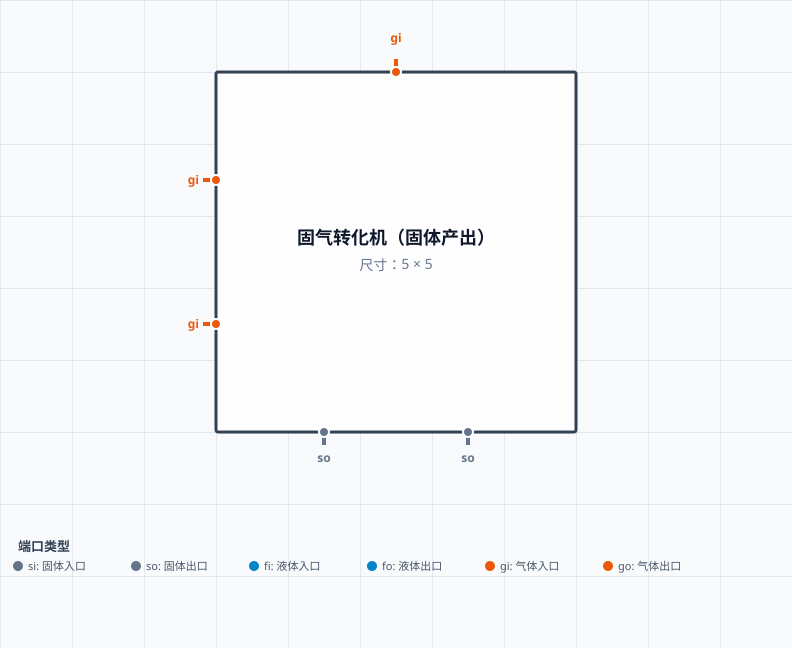

SVG 已保存：images\固气转化机（固体产出）.svg


In [35]:
draw_device("固气转化机（固体产出）")